In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('content/spam.csv', encoding='latin-1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4874,ham,I know dat feelin had it with Pete! Wuld get w...,NaN,NaN,NaN
5464,ham,I will treasure every moment we spend together...,NaN,NaN,NaN
4014,spam,You will be receiving this week's Triple Echo ...,NaN,NaN,NaN
4544,ham,Never y lei... I v lazy... Got wat? Dat day Ì_...,NaN,NaN,NaN
3760,ham,Was just about to ask. Will keep this one. May...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
df.sample(5)

,v1,v2
2765,ham,and picking them up from various points
2741,spam,I don't know u and u don't know me. Send CHAT ...
2317,ham,Waqt se pehle or naseeb se zyada kisi ko kuch ...
302,ham,Oh and by the way you do have more food in you...
3319,ham,Eh sorry leh... I din c ur msg. Not sad alread...


In [9]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1990,ham,HI DARLIN IVE JUST GOT BACK AND I HAD A REALLY...
1425,ham,I'll be at mu in like &lt;#&gt; seconds
91,ham,Sorry to be a pain. Is it ok if we meet anothe...
947,ham,Hey i booked the kb on sat already... what oth...
3529,ham,Tyler (getting an 8th) has to leave not long a...


In [10]:
from sklearn.preprocessing import LabelEncoder    # Import LabelEncoder to convert categorical labels into numeric form

encoder = LabelEncoder()                         # Create an instance of LabelEncoder to use for encoding labels

In [11]:
df['target'] = encoder.fit_transform(df['target'])   # Convert 'target' column (spam/ham) into numeric values (1/0)

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [15]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(5169, 2)

## 2.EDA

In [18]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

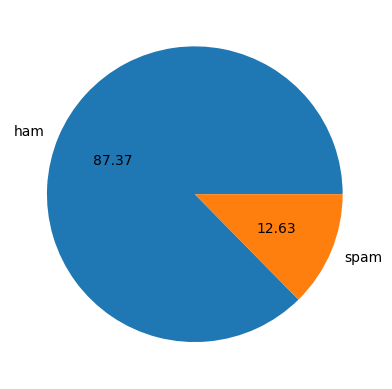

In [20]:
import matplotlib.pyplot as plt                      # Import matplotlib for plotting graphs

plt.pie(df['target'].value_counts(),                 # Count number of ham & spam messages
        labels=['ham','spam'],                       # Labels for each slice of pie chart
        autopct="%0.2f")                             # Show percentage with 2 decimal places

plt.show()                                           # Display the pie chart

In [21]:
# Data is imbalanced

In [22]:
# !pip install nltk

In [23]:
import nltk

In [24]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aayu0\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
df['num_characters'] = df['text'].apply(len)

In [26]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [27]:
import nltk                                # Import NLTK library for text preprocessing

nltk.download('punkt')                     # Download tokenizer models (used for splitting text into words/sentences)

nltk.download('stopwords')                 # Download list of common stopwords (like is, the, and)

nltk.download('punkt_tab')                 # Download additional tokenizer resources (sometimes required in newer setups)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aayu0\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aayu0\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aayu0\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [29]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [30]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [31]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [32]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [35]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

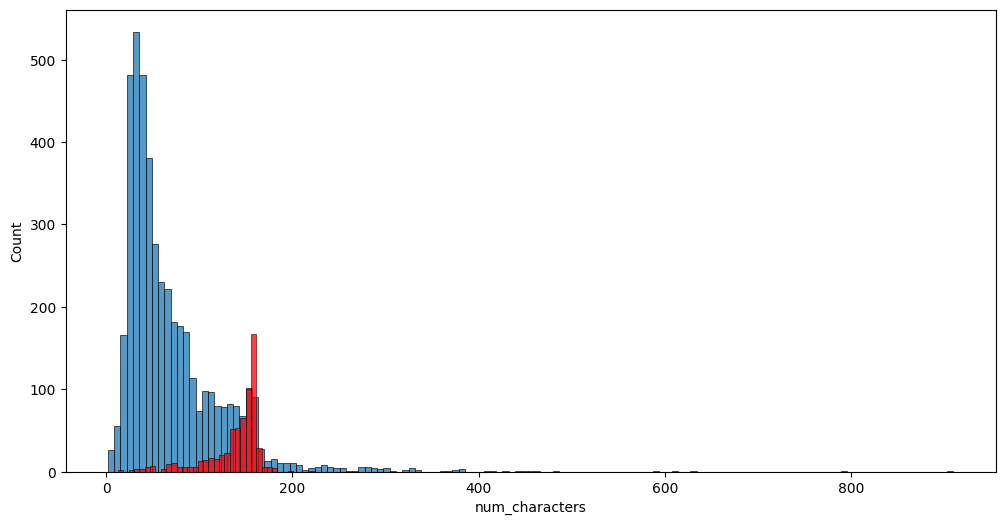

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

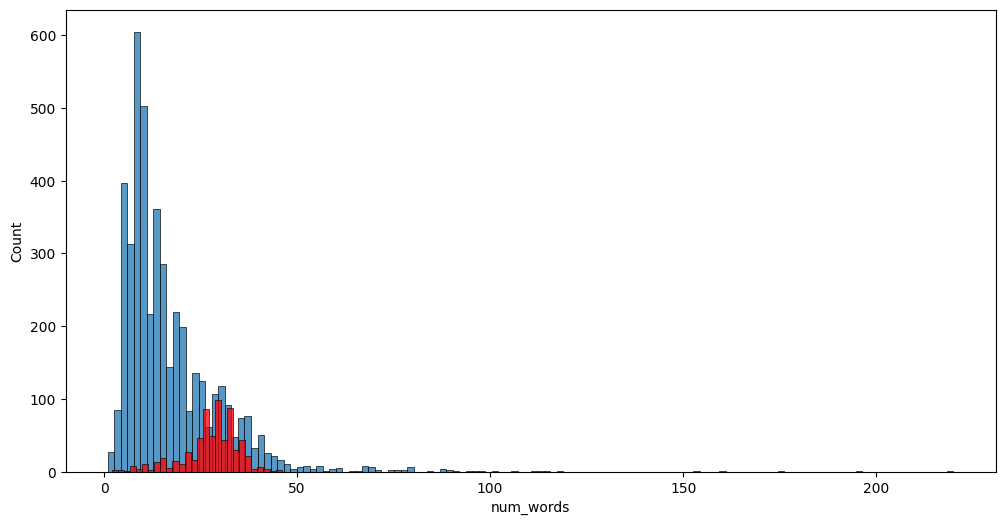

In [37]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

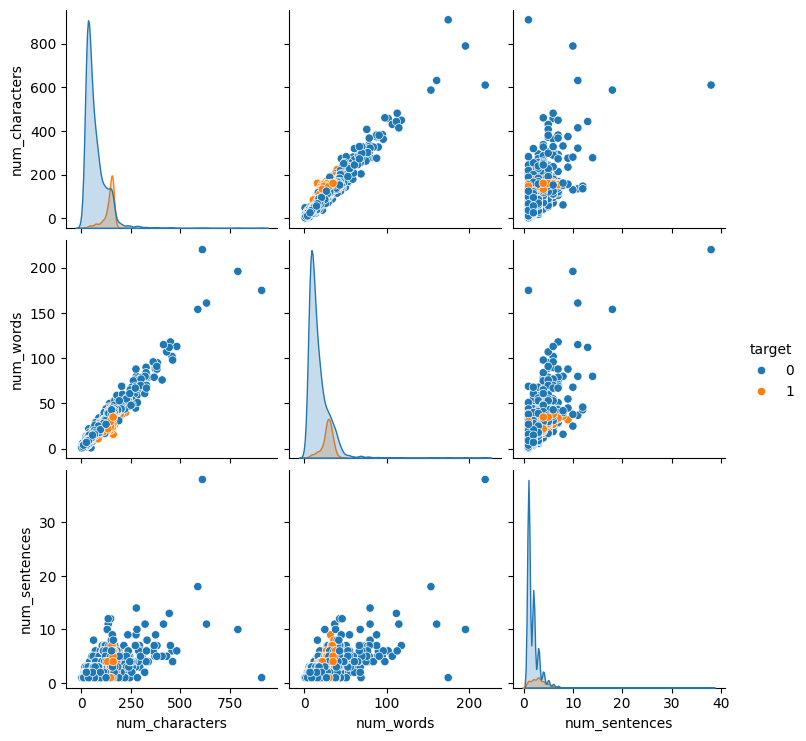

In [38]:
sns.pairplot(df,hue='target')

<Axes: >

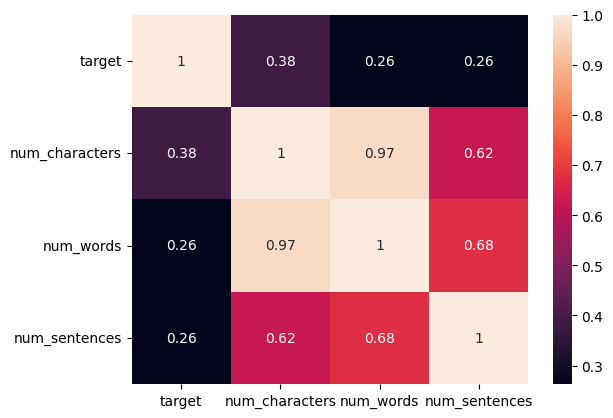

In [39]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [40]:
import nltk                                      # Import NLTK for text processing
from nltk.corpus import stopwords                # Import stopwords list
from nltk.stem.porter import PorterStemmer       # Import stemming tool
import string                                    # Import string module for punctuation

ps = PorterStemmer()                             # Create stemmer object
stop_words = set(stopwords.words('english'))     # Load stopwords once for faster access

def transform_text(text):
    text = text.lower()                          # Convert text to lowercase
    text = nltk.word_tokenize(text)              # Tokenize text into words

    y = []
    for i in text:
        if i.isalnum():                          # Keep only alphanumeric words
            y.append(i)

    text = y[:]                                  # Copy filtered words
    y.clear()                                    # Clear list for reuse

    for i in text:
        if i not in stop_words and i not in string.punctuation:
            y.append(i)                          # Remove stopwords & punctuation

    text = y[:]                                  # Copy cleaned words
    y.clear()                                    # Clear list

    for i in text:
        y.append(ps.stem(i))                     # Apply stemming (root form)

    return " ".join(y)                           # Join words into final cleaned text

In [41]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [42]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [43]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [44]:
df['transformed_text'] = df['text'].apply(transform_text)

In [45]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [46]:
# !pip install wordcloud

In [47]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [48]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

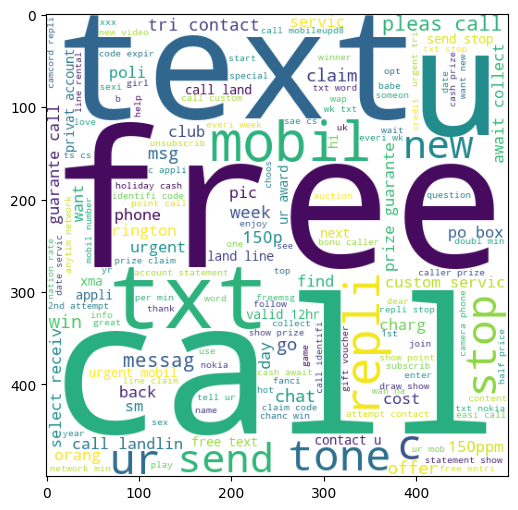

In [49]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [50]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

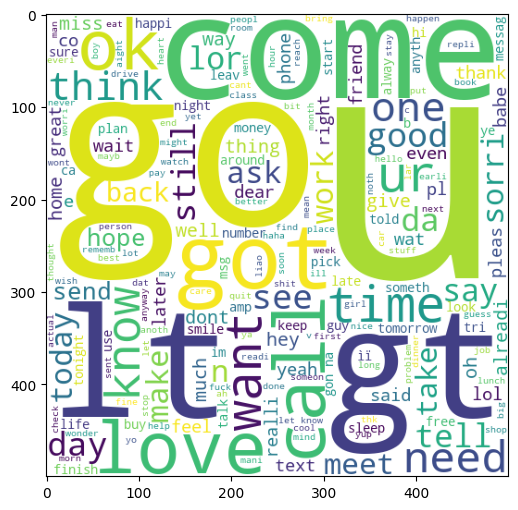

In [51]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [52]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
spam_corpus = []                                                # Create empty list to store all spam words

for msg in df[df['target'] == 1]['transformed_text'].tolist():   # Loop through all spam messages (target = 1)
    for word in msg.split():                                     # Split each message into individual words
        spam_corpus.append(word)                                 # Add each word to spam_corpus list

In [54]:
len(spam_corpus)

9939

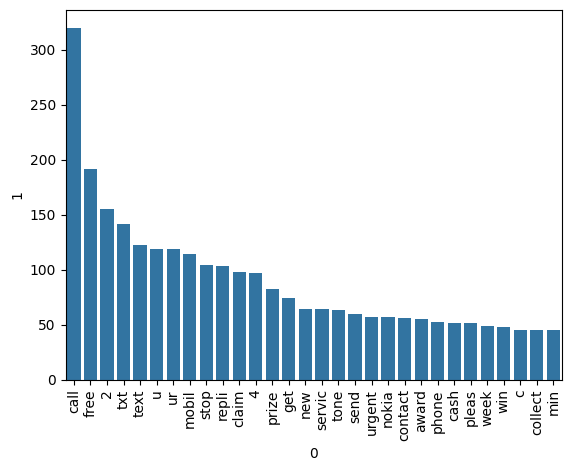

In [55]:
from collections import Counter
import pandas as pd

data = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=data[0], y=data[1])
plt.xticks(rotation='vertical')
plt.show()

In [56]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [57]:
len(ham_corpus)

35404

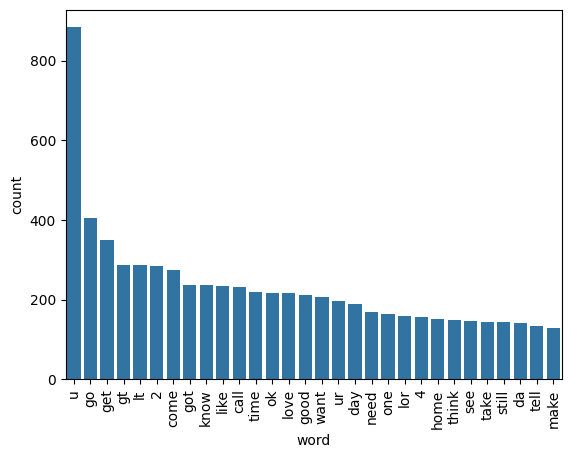

In [ ]:
data = pd.DataFrame(Counter(ham_corpus).most_common(30),   # Get top 30 most frequent words from ham messages
                    columns=['word','count'])              # Name the columns as 'word' and 'count'

sns.barplot(x='word', y='count', data=data)                # Plot bar graph using column names

plt.xticks(rotation='vertical')                            # Rotate x-axis labels for better readability

plt.show()                                                 # Display the graph

In [59]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. Model Building

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer   # Import vectorizers for text to numeric conversion

cv = CountVectorizer()                                                          # Convert text into word count (Bag of Words)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))                  # Convert text using TF-IDF (importance-based)
                                                                               # max_features=5000 → use top 5000 words
                                                                               # ngram_range=(1,2) → use unigrams + bigrams

In [ ]:
X = tfidf.fit_transform(df['transformed_text']).toarray()   # Convert cleaned text into numerical feature matrix using TF-IDF
                                                           # fit → learn vocabulary
                                                           # transform → convert text into vectors
                                                           # toarray() → convert sparse matrix to normal array

In [62]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [63]:
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [64]:
X.shape

(5169, 5000)

In [65]:
y = df['target'].values

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler()
X, y = ros.fit_resample(X, y)


In [68]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [69]:
# !pip install imblearn

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB   # Import different Naive Bayes models

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score  # Import evaluation metrics

In [ ]:
gnb = GaussianNB()            # Create Gaussian Naive Bayes model (for continuous data)

mnb = MultinomialNB()         # Create Multinomial Naive Bayes model (best for text data)

bnb = BernoulliNB()           # Create Bernoulli Naive Bayes model (for binary features)

In [ ]:
gnb.fit(X_train, y_train)                          # Train GaussianNB model using training data

y_pred1 = gnb.predict(X_test)                      # Predict labels for test data

print(accuracy_score(y_test, y_pred1))             # Print accuracy (overall correct predictions)

print(confusion_matrix(y_test, y_pred1))           # Print confusion matrix (detailed performance)

print(precision_score(y_test, y_pred1))            # Print precision (important for spam detection)

0.9446596568898727
[[806 100]
 [  0 901]]
0.9000999000999002


In [73]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9623685666851135
[[873  33]
 [ 35 866]]
0.9632925472747497


In [74]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9568345323741008
[[906   0]
 [ 78 823]]
1.0


In [75]:
# tfidf --> MNB

In [76]:
# !pip install xgboost

In [ ]:
from sklearn.linear_model import LogisticRegression        # Linear model for classification

from sklearn.svm import SVC                                # Support Vector Machine classifier

from sklearn.naive_bayes import MultinomialNB              # Naive Bayes (best for text data)

from sklearn.tree import DecisionTreeClassifier            # Tree-based model

from sklearn.neighbors import KNeighborsClassifier         # KNN (distance-based model)

from sklearn.ensemble import RandomForestClassifier        # Ensemble of multiple decision trees

from sklearn.ensemble import AdaBoostClassifier            # Boosting algorithm (focuses on mistakes)

from sklearn.ensemble import BaggingClassifier             # Reduces variance using multiple models

from sklearn.ensemble import ExtraTreesClassifier          # Randomized trees (faster than RandomForest)

from sklearn.ensemble import GradientBoostingClassifier    # Sequential boosting model

from xgboost import XGBClassifier                          # Advanced boosting model (very powerful)

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)                 # SVM model with sigmoid kernel

knc = KNeighborsClassifier()                          # KNN model (uses nearest neighbors)

mnb = MultinomialNB()                                 # Naive Bayes (best for text data)

dtc = DecisionTreeClassifier(max_depth=5)             # Decision Tree with limited depth (avoid overfitting)

lrc = LogisticRegression(solver='liblinear', 
                         penalty='l1')                # Logistic Regression with L1 regularization (feature selection)

rfc = RandomForestClassifier(n_estimators=50, 
                             random_state=2)          # Random Forest with 50 trees

abc = AdaBoostClassifier(n_estimators=50, 
                         random_state=2)              # AdaBoost with 50 weak learners

bc = BaggingClassifier(n_estimators=50, 
                       random_state=2)                # Bagging with 50 models

etc = ExtraTreesClassifier(n_estimators=50, 
                           random_state=2)            # Extra Trees (more randomness)

gbdt = GradientBoostingClassifier(n_estimators=50, 
                                  random_state=2)     # Gradient Boosting model

xgb = XGBClassifier(n_estimators=50, 
                    random_state=2)                   # XGBoost (advanced boosting model)

In [79]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [80]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [81]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9795240730492529, 0.9810690423162584)

In [82]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9795240730492529
Precision -  0.9810690423162584
For  KN
Accuracy -  0.5777531820697288
Precision -  0.5414663461538461
For  NB
Accuracy -  0.9623685666851135
Precision -  0.9632925472747497
For  DT
Accuracy -  0.8655229662423907
Precision -  0.9071782178217822


C:\Users\Aayu0\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Aayu0\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  LR
Accuracy -  0.9717764250138351
Precision -  0.9722222222222222
For  RF
Accuracy -  0.9955727725511898
Precision -  0.9944629014396457
For  AdaBoost
Accuracy -  0.866076369673492
Precision -  0.924066924066924
For  BgC
Accuracy -  0.96956281128943
Precision -  0.9452631578947368
For  ETC
Accuracy -  0.9983397897066962
Precision -  1.0
For  GBDT
Accuracy -  0.9114554510237963
Precision -  0.9384615384615385
For  xgb
Accuracy -  0.9645821804095185
Precision -  0.9665551839464883


In [83]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [84]:
performance_df

,Algorithm,Accuracy,Precision
8,ETC,0.998340,1.000000
5,RF,0.995573,0.994463
0,SVC,0.979524,0.981069
4,LR,0.971776,0.972222
10,xgb,0.964582,0.966555
2,NB,0.962369,0.963293
7,BgC,0.969563,0.945263
9,GBDT,0.911455,0.938462
6,AdaBoost,0.866076,0.924067
3,DT,0.865523,0.907178


In [85]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [86]:
performance_df1

,Algorithm,variable,value
0,ETC,Accuracy,0.998340
1,RF,Accuracy,0.995573
2,SVC,Accuracy,0.979524
3,LR,Accuracy,0.971776
4,xgb,Accuracy,0.964582
5,NB,Accuracy,0.962369
6,BgC,Accuracy,0.969563
7,GBDT,Accuracy,0.911455
8,AdaBoost,Accuracy,0.866076
9,DT,Accuracy,0.865523


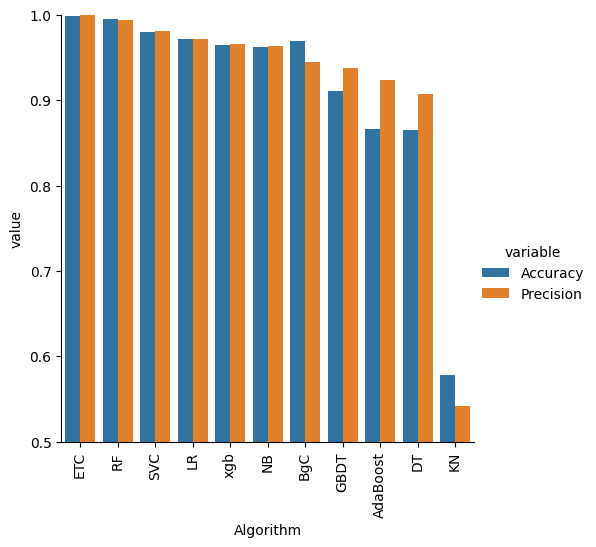

In [87]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [88]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [89]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [90]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [91]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [92]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [93]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [94]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,ETC,0.998340,1.000000,0.998340,1.000000,0.998340,1.000000,0.998340,1.000000
1,RF,0.995573,0.994463,0.995573,0.994463,0.995573,0.994463,0.995573,0.994463
2,SVC,0.979524,0.981069,0.979524,0.981069,0.979524,0.981069,0.979524,0.981069
3,LR,0.971776,0.972222,0.971776,0.972222,0.971776,0.972222,0.971776,0.972222
4,xgb,0.964582,0.966555,0.964582,0.966555,0.964582,0.966555,0.964582,0.966555
5,NB,0.962369,0.963293,0.962369,0.963293,0.962369,0.963293,0.962369,0.963293
6,BgC,0.969563,0.945263,0.969563,0.945263,0.969563,0.945263,0.969563,0.945263
7,GBDT,0.911455,0.938462,0.911455,0.938462,0.911455,0.938462,0.911455,0.938462
8,AdaBoost,0.866076,0.924067,0.866076,0.924067,0.866076,0.924067,0.866076,0.924067
9,DT,0.865523,0.907178,0.865523,0.907178,0.865523,0.907178,0.865523,0.907178


In [95]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [96]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [97]:
voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [98]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9922523519645822
Precision 0.9922308546059934


In [99]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [100]:
from sklearn.ensemble import StackingClassifier

In [101]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [102]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9983397897066962
Precision 1.0


In [103]:
import pickle
from sklearn.linear_model import LogisticRegression


print("Training final model...")

# # ! Train final model properly
# final_model = MultinomialNB()
# final_model.fit(X_train, y_train)

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train, y_train)

print("Saving files...")

# ! Save vectorizer
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# ! Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Saved successfully ✅")

Training final model...
Saving files...
Saved successfully ✅


In [104]:
import os

print("Vectorizer size:", os.path.getsize("vectorizer.pkl"))
print("Model size:", os.path.getsize("model.pkl"))

Vectorizer size: 187011
Model size: 40710
